In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [19]:
df = pd.read_csv(
    "../data/simulated/nova_retail_simulated_data_v1.csv"
)

print(df.shape)

df.head()

(2924000, 27)


,date,year,month,week,day_of_week,region,store_id,channel,category,sku,product_type,base_price,price,cost,true_price_elasticity,seasonality_strength,base_daily_demand,event_name,event_phase,base_event_multiplier,event_multiplier,price_index,price_effect,expected_units,units,revenue,gross_profit
0,2024-01-01,2024,1,1,Monday,West,STORE_01,Web,Electronics,SKU_001,Seasonal,653.53,665.48,412.67,-1.2,1.5,12.30,No Event,normal,1.0,1.0,1.018283,0.978491,10.136319,9,5989.32,2275.29
1,2024-01-01,2024,1,1,Monday,West,STORE_01,App,Electronics,SKU_001,Seasonal,653.53,612.75,412.67,-1.2,1.5,12.30,No Event,normal,1.0,1.0,0.937601,1.080385,9.452502,17,10416.75,3401.36
2,2024-01-01,2024,1,1,Monday,West,STORE_01,BOPIS,Electronics,SKU_001,Seasonal,653.53,682.96,412.67,-1.2,1.5,12.30,No Event,normal,1.0,1.0,1.045027,0.948515,10.923329,9,6146.64,2432.61
3,2024-01-01,2024,1,1,Monday,West,STORE_01,Store,Electronics,SKU_001,Seasonal,653.53,690.41,412.67,-1.2,1.5,12.30,No Event,normal,1.0,1.0,1.056434,0.936246,15.093168,13,8975.33,3610.62
4,2024-01-01,2024,1,1,Monday,West,STORE_01,Web,Electronics,SKU_002,Seasonal,817.53,721.83,550.55,-1.2,1.5,26.05,No Event,normal,1.0,1.0,0.882938,1.161134,25.949952,22,15880.26,3768.16


In [20]:
df.describe()

,year,month,week,base_price,price,cost,true_price_elasticity,seasonality_strength,base_daily_demand,base_event_multiplier,event_multiplier,price_index,price_effect,expected_units,units,revenue,gross_profit
count,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06,2.924000e+06
mean,2.024499e+03,6.519836e+00,2.639535e+01,4.452084e+02,4.452184e+02,2.932996e+02,-1.428000e+00,1.175000e+00,2.691060e+01,1.037073e+00,1.043560e+00,1.000042e+00,1.006672e+00,2.836692e+01,2.836732e+01,1.133572e+04,3.541038e+03
std,4.999996e-01,3.449551e+00,1.506597e+01,2.999591e+02,3.016835e+02,1.937282e+02,4.783472e-01,3.434022e-01,1.807420e+01,2.242493e-01,2.748105e-01,5.994080e-02,9.260585e-02,2.437064e+01,2.494546e+01,1.377094e+04,4.285131e+03
min,2.024000e+03,1.000000e+00,1.000000e+00,3.312000e+01,2.650000e+01,2.544000e+01,-2.000000e+00,6.000000e-01,5.610000e+00,8.500000e-01,7.750000e-01,8.000000e-01,6.944354e-01,1.345485e+00,0.000000e+00,0.000000e+00,-8.849400e+02
25%,2.024000e+03,4.000000e+00,1.300000e+01,1.852700e+02,1.859300e+02,1.297800e+02,-2.000000e+00,1.150000e+00,1.083000e+01,9.000000e-01,9.400000e-01,9.596130e-01,9.497258e-01,1.087493e+01,1.100000e+01,2.995088e+03,9.169275e+02
50%,2.024000e+03,7.000000e+00,2.600000e+01,4.052300e+02,3.987600e+02,2.838600e+02,-1.200000e+00,1.300000e+00,2.230000e+01,1.000000e+00,1.000000e+00,1.000024e+00,1.000000e+00,2.100705e+01,2.100000e+01,6.283710e+03,1.980930e+03
75%,2.025000e+03,1.000000e+01,3.900000e+01,7.170500e+02,7.015200e+02,4.216400e+02,-1.200000e+00,1.500000e+00,3.957000e+01,1.000000e+00,1.000000e+00,1.040538e+00,1.055269e+00,3.822863e+01,3.800000e+01,1.439088e+04,4.654740e+03
max,2.025000e+03,1.200000e+01,5.200000e+01,1.082540e+03,1.299050e+03,7.437300e+02,-8.000000e-01,1.500000e+00,6.991000e+01,2.000000e+00,2.500000e+00,1.200000e+00,1.562530e+00,4.942856e+02,5.140000e+02,3.095902e+05,1.139917e+05


In [21]:
df["event_name"].value_counts()

event_name
No Event            1736000
Memorial Day         280000
Independence Day     280000
Labor Day            280000
Holiday Season       192000
Cyber Monday         132000
Black Friday          24000
Name: count, dtype: int64

In [25]:
black_friday = df[
    df["event_name"]=="Black Friday"
]

normal = df[
    df["event_name"]=="No Event"
]       

In [27]:
print(
    "Black Friday Avg Units:",
    black_friday["units"].mean()
)

print(
    "Normal Avg Units:",
    normal["units"].mean()
)

Black Friday Avg Units: 22.004375
Normal Avg Units: 27.10966013824885


In [28]:
df.groupby(
    "event_phase"
)["units"].mean()

event_phase
event         45.643834
normal        27.109660
post_event    22.011092
pre_event     23.608636
Name: units, dtype: float64

In [29]:
seasonality_check = (
    df.groupby(
        ["product_type","event_phase"]
    )["units"]
    .mean()
    .reset_index()
)

seasonality_check

,product_type,event_phase,units
0,Commodity,event,62.671404
1,Commodity,normal,36.683406
2,Commodity,post_event,29.596071
3,Commodity,pre_event,31.797331
4,Premium,event,17.864879
5,Premium,normal,13.447967
6,Premium,post_event,12.225546
7,Premium,pre_event,12.599002
8,Promo Sensitive,event,51.061165
9,Promo Sensitive,normal,31.405929


In [30]:
pivot = seasonality_check.pivot(
    index="product_type",
    columns="event_phase",
    values="units"
)

pivot

event_phase,event,normal,post_event,pre_event
product_type,,,,
Commodity,62.671404,36.683406,29.596071,31.797331
Premium,17.864879,13.447967,12.225546,12.599002
Promo Sensitive,51.061165,31.405929,25.867347,27.686320
Seasonal,48.144622,26.500925,20.552223,22.404972


In [31]:
sku = "SKU_001"

sku_df = df[
    df["sku"] == sku
]

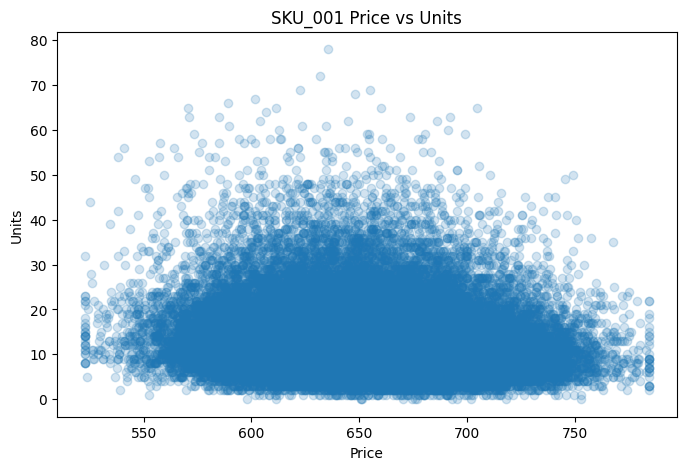

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(
    sku_df["price"],
    sku_df["units"],
    alpha=0.2
)

plt.xlabel("Price")
plt.ylabel("Units")
plt.title(f"{sku} Price vs Units")

plt.show()

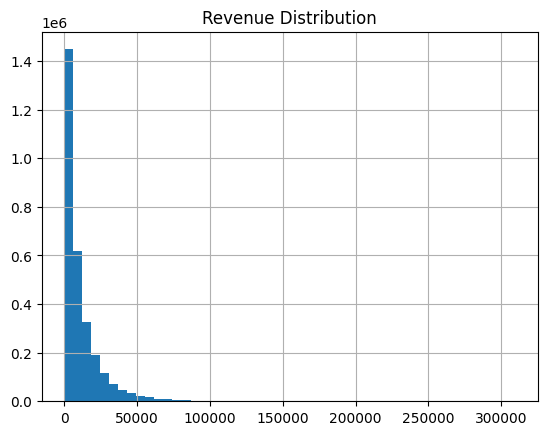

In [33]:
df["revenue"].hist(
    bins=50
)
plt.title("Revenue Distribution")
plt.show()

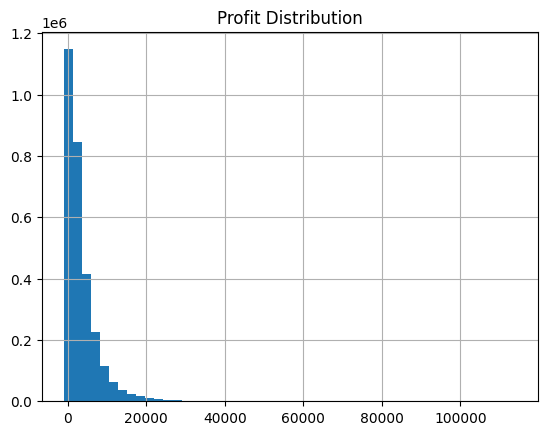

In [34]:
df["gross_profit"].hist(
    bins=50
)
plt.title("Profit Distribution")
plt.show()

In [35]:
(
    df.groupby("event_name")
    ["units"]
    .mean()
    .sort_values(
        ascending=False
    )
)

event_name
Holiday Season      52.032708
Cyber Monday        30.502879
No Event            27.109660
Labor Day           25.734629
Memorial Day        25.410986
Independence Day    25.064725
Black Friday        22.004375
Name: units, dtype: float64

In [36]:
df["event_phase"].value_counts()

event_phase
normal        1736000
pre_event      472000
event          380000
post_event     336000
Name: count, dtype: int64

In [37]:
df["event_name"].unique()

<ArrowStringArray>
[        'No Event',     'Memorial Day', 'Independence Day',
        'Labor Day',     'Black Friday',     'Cyber Monday',
   'Holiday Season']
Length: 7, dtype: str

In [38]:
sku_df.groupby(
    pd.cut(sku_df["price"], 10)
)["units"].mean()

price
(522.559, 548.962]    16.171429
(548.962, 575.104]    15.563910
(575.104, 601.246]    14.742598
(601.246, 627.388]    13.968450
(627.388, 653.53]     13.250483
(653.53, 679.672]     12.642489
(679.672, 705.814]    12.172695
(705.814, 731.956]    11.638557
(731.956, 758.098]    11.431569
(758.098, 784.24]     10.778325
Name: units, dtype: float64

In [54]:
import pandas as pd

df = pd.read_csv(
    "../data/simulated/nova_retail_simulated_data_v2_inventory.csv"
)

print(df.shape)

print(df["stock_status"].value_counts(normalize=True))

print(df[["demand_units", "units", "lost_sales"]].describe())

print(
    df.groupby("event_phase")[["demand_units", "units", "lost_sales"]].mean()
)

(2924000, 37)
stock_status
In Stock                0.616630
Low Stock               0.374717
Limited Availability    0.007580
Out Of Stock            0.001074
Name: proportion, dtype: float64
       demand_units         units    lost_sales
count  2.924000e+06  2.924000e+06  2.924000e+06
mean   2.836732e+01  2.836130e+01  6.015732e-03
std    2.494546e+01  2.492183e+01  3.719510e-01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.100000e+01  1.100000e+01  0.000000e+00
50%    2.100000e+01  2.100000e+01  0.000000e+00
75%    3.800000e+01  3.800000e+01  0.000000e+00
max    5.140000e+02  4.380000e+02  1.230000e+02
             demand_units      units  lost_sales
event_phase                                     
event           45.643834  45.602208    0.041626
normal          27.109660  27.108791    0.000869
post_event      22.011092  22.010890    0.000202
pre_event       23.608636  23.608222    0.000413


In [57]:
print(
    (df["demand_units"] > df["starting_inventory"]).mean()
)

0.000807797537619699


In [58]:
df[[
    "demand_units",
    "starting_inventory"
]].describe()

,demand_units,starting_inventory
count,2.924000e+06,2.924000e+06
mean,2.836732e+01,9.833548e+01
std,2.494546e+01,7.596959e+01
min,0.000000e+00,1.200000e+01
25%,1.100000e+01,3.600000e+01
50%,2.100000e+01,7.700000e+01
75%,3.800000e+01,1.400000e+02
max,5.140000e+02,4.840000e+02


In [59]:
df.groupby("stock_status")["units"].mean()

stock_status
In Stock                25.292310
Limited Availability    45.870189
Low Stock               32.977705
Out Of Stock            56.189551
Name: units, dtype: float64

In [60]:
df.groupby("stock_status")["lost_sales"].mean()

stock_status
In Stock                0.000000
Limited Availability    0.000000
Low Stock               0.000000
Out Of Stock            5.603695
Name: lost_sales, dtype: float64